<a href="https://colab.research.google.com/github/goetzdominik/Digichem/blob/main/jonas_digichem_dataset_creation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade numpy
!pip install --upgrade mendeleev
!pip install --upgrade pymatgen


In [4]:
import pandas as pd
import numpy as np
import pymatgen
from pymatgen.core import Element
from mendeleev import element

import ast

pd.set_option('display.max_rows', 100)  # Display 10 rows
pd.set_option('display.max_columns', None)  # Display all columns

df_ABC3 = pd.read_csv("../ABC3_filtered.csv")
df_A2BCX6 = pd.read_csv("../A2BCX6_filtered.csv")

#Merge the two pervoskites data frames and treat them as one
df = pd.concat([df_ABC3, df_A2BCX6], axis=0,ignore_index=True)
df.to_csv("df.csv", index=False)
print(df)

C:\Users\moorh\AppData\Local\Temp\ipykernel_836\4113363447.py:12: DtypeWarning: Columns (64,334,436,534,540,570,602,608,614,620,690,696,704,710,716,722,728,772,778,784,790,796,802,808,814,834,846,858,870,896,902,908,914,920,960,966,972,978,992,998,1004,1010,1016,1022,1028,1034,1085,1086,1088,1089,1090,1092,1095,1096,1098,1099,1101,1102,1103,1105,1108,1109,1137,1138,1140,1141,1142,1143,1144,1147,1148,1150,1151,1153,1154,1155,1156,1157,1160,1161,1189,1190,1192,1193,1194,1196,1199,1200,1202,1203,1205,1206,1207,1209,1212,1213,1214,1220,1226,1232,1262,1268,1274,1280,1301,1302,1303,1304,1305,1306,1313,1314,1315,1316,1317,1318,1349,1350,1351,1352,1353,1354,1361,1362,1363,1364,1365,1366,1397,1398,1399,1400,1401,1402,1409,1410,1411,1412,1413,1414,1433,1439,1445,1451,1562,1564,1582,1583,1584,1585,1586,1587,1588,1589,1590,1591,1592,1593,1631,1632,1633,1634,1636,1637,1638,1639,1640,1641,1661,1662,1663,1664,1665,1666,1667,1668,1669,1670,1671,1672,1673,1674,1675,1676,1677,1678,1679,1680,1686,1691,16

In [ ]:
#test mendeleev package
Fe = element("Fe")

print(Fe.fusion_heat)
print(Fe.evaporation_heat)
print(Fe.specific_heat)
print(Fe.electrons)

In [ ]:
#test pymatgen package
element = Element("Fe")  # Iron

print(element.Z)
print(element.group)
print(element.row)
print(element.mendeleev_no)
print(element.iupac_ordering)
print(element.average_ionic_radius)
print(element.atomic_radius)
print(element.atomic_radius_calculated)
print(element.van_der_waals_radius)
print(element.X)
print(element.electron_affinity)
print(element.ionization_energy)
print(element.valence[1])
print(element.atomic_mass)
print(element.density_of_solid)
print(element.molar_volume)
print(element.boiling_point)
print(element.melting_point)
print(element.thermal_conductivity)


In [5]:
#add the missing values to the mendeleev functions of fusion heat, evaporation heat and specific heat (and BP)
missing_fusion_heats = {
    "As": 24.44,  # kJ/mol
    "O" : 0.44,
    "N" : 0.72,
    "C" : 117,
    "Ru" : 38.59,
    "Tb" : 10.15,
    "Gd" : 10.05,
    "Dy" : 11.06,
    "Eu" : 9.21,
    "Ho" : 17.0,
    "Er" : 19.9,
    "Lu" : 22,
    "Tm" : 16.84
}

from mendeleev import element

def get_fusion_heat(element_symbol):
    elmt = element(element_symbol)
    if elmt.fusion_heat is None and element_symbol in missing_fusion_heats:
        return missing_fusion_heats[element_symbol]
    elif elmt.fusion_heat is None and element_symbol not in missing_fusion_heats:
        print(elmt.name, "is missing fusion heat value")
    else:
        return elmt.fusion_heat

missing_evaporation_heats = {
    "O" : 6.82, # kJ/mol
    "N" : 5.58,
    "C" : 715,
    "Ru" : 619,
    "Tb" : 391
}

from mendeleev import element

def get_evaporation_heat(element_symbol):
    elmt = element(element_symbol)
    if elmt.evaporation_heat is None and element_symbol in missing_evaporation_heats:
        return missing_evaporation_heats[element_symbol]
    else:
        return elmt.evaporation_heat

missing_specific_heats = {
    "Pa" : 99.1,
    "Tc" : 63
}

def get_specific_heat(element_symbol):
    elmt = element(element_symbol)
    if elmt.specific_heat is None and element_symbol in missing_specific_heats:
        return missing_specific_heats[element_symbol]
    else:
        return elmt.specific_heat

def get_boiling_point(element_symbol):
    elmt = element(element_symbol)
    if element_symbol == "Pa":
        return 4000
    elif element_symbol == "P":
        return 550
    else:
        return elmt.boiling_point

In [6]:
#define function to handle missing values (use atomic radius instead of calculated and use atomic mass/molar volume instead of density of solid)
def get_atomic_radius_calculated(elmt_pymatgen_temp):
    atomic_radius_calculated_temp = elmt_pymatgen_temp.atomic_radius_calculated
    if atomic_radius_calculated_temp == None:
        return elmt_pymatgen_temp.atomic_radius
    else :
      return atomic_radius_calculated_temp

def get_density_of_solid(elmt_pymatgen_temp):
    density_of_solid_temp = elmt_pymatgen_temp.density_of_solid
    if density_of_solid_temp == None:
        return elmt_pymatgen_temp.atomic_mass / elmt_pymatgen_temp.molar_volume *1000
    else :
      return density_of_solid_temp

In [7]:
#create dictionary with the values for all elements (so that the loop over all formulas is faster) (takes approx 4 minutes now)

#find all elements in the csv file to create input for dictionary creation
elements_list = pd.read_csv('df.csv', usecols= ['elements'])
elements_vector = []
for index in elements_list.index: # Iterate over DataFrame index to get row
  formula = elements_list.loc[index, 'elements'] # Access element string using loc
  formula = ast.literal_eval(formula) # Safely evaluate string as list
  for elmt in formula:
    elements_vector.append(elmt)

elements_vector = pd.Series(elements_vector).drop_duplicates().tolist() # Deduplicate elements


#loop over the found unique elements and define the needed properties
elemental_properties = {}  #dictionary to be filled

for symbol in elements_vector:
    #define strings as "elements"
    elmt_pymatgen = Element(symbol)
    elmt_mendeleev = element(symbol)

    properties = {
        'atomic_mass': elmt_pymatgen.atomic_mass,
        'Z': elmt_pymatgen.Z,
        'group': elmt_pymatgen.group,
        'fusion_heat': get_fusion_heat(symbol),  # Use custom function
        'evaporation_heat': get_evaporation_heat(symbol),  # Use custom function
        'specific_heat': get_specific_heat(symbol), # Use custom function
        'row': elmt_pymatgen.row,
        'mendeleev_no': elmt_pymatgen.mendeleev_no,
        'iupac_ordering': elmt_pymatgen.iupac_ordering,
        'average_ionic_radius': elmt_pymatgen.average_ionic_radius,
        'atomic_radius': elmt_pymatgen.atomic_radius,
        'atomic_radius_calculated': get_atomic_radius_calculated(elmt_pymatgen), # Use custom function
        'van_der_waals_radius': elmt_pymatgen.van_der_waals_radius,
        'X': elmt_pymatgen.X,
        'electron_affinity': elmt_pymatgen.electron_affinity,
        'ionization_energy': elmt_pymatgen.ionization_energy,
    #    'valence': elmt_pymatgen.valence[1],
        'density_of_solid': get_density_of_solid(elmt_pymatgen), # Use custom function
        'molar_volume': elmt_pymatgen.molar_volume,
        'boiling_point': get_boiling_point(symbol), # Use custom function
        'melting_point': elmt_pymatgen.melting_point,
        'thermal_conductivity': elmt_pymatgen.thermal_conductivity

    }

    elemental_properties[symbol] = properties  # For dictionary


C:\Users\moorh\AppData\Local\Temp\ipykernel_836\2885943200.py:10: UserWarning: No data available for density_of_solid for Br
  density_of_solid_temp = elmt_pymatgen_temp.density_of_solid
C:\Users\moorh\AppData\Local\Temp\ipykernel_836\2885943200.py:10: UserWarning: No data available for density_of_solid for O
  density_of_solid_temp = elmt_pymatgen_temp.density_of_solid
C:\Users\moorh\AppData\Local\Temp\ipykernel_836\2885943200.py:10: UserWarning: No data available for density_of_solid for Cl
  density_of_solid_temp = elmt_pymatgen_temp.density_of_solid
C:\Users\moorh\AppData\Local\Temp\ipykernel_836\2885943200.py:10: UserWarning: No data available for density_of_solid for N
  density_of_solid_temp = elmt_pymatgen_temp.density_of_solid
C:\Users\moorh\AppData\Local\Temp\ipykernel_836\2885943200.py:10: UserWarning: No data available for density_of_solid for F
  density_of_solid_temp = elmt_pymatgen_temp.density_of_solid
C:\Users\moorh\AppData\Local\Temp\ipykernel_836\2885943200.py:3: Use

In [8]:
#get only relevant columns from materials project file
df = pd.read_csv('df.csv', usecols= ['formula_pretty','elements', 'band_gap','energy_above_hull','formation_energy_per_atom','density','structure.sites'])

#loop over all entries and extract the corresponding elements
index = -1
for formula in df["elements"]:
  index += 1
  #reformat to list
  elements = ast.literal_eval(formula)

  #calculate property and mean/sd
  atomic_mass = []
  Z = []
  group = []
  row = []
  mendeleev_no = []
  iupac_ordering = []
  average_ionic_radius = []
  atomic_radius = []
  atomic_radius_calculated = []
  van_der_waals_radius = []
  X = []
  electron_affinity = []
  ionization_energy = []
  valence = []
  atomic_mass = []
  density_of_solid = []
  molar_volume = []
  fusion_heat = []
  evaporation_heat = []
  specific_heat = []

#use the library to assign the properties
  for elmt in elements:

    atomic_mass.append(elemental_properties[elmt]['atomic_mass'])
    Z.append(elemental_properties[elmt]['Z'])
    group.append(elemental_properties[elmt]['group'])
    row.append(elemental_properties[elmt]['row'])
    mendeleev_no.append(elemental_properties[elmt]['mendeleev_no'])
    iupac_ordering.append(elemental_properties[elmt]['iupac_ordering'])
    average_ionic_radius.append(elemental_properties[elmt]['average_ionic_radius'])
    atomic_radius.append(elemental_properties[elmt]['atomic_radius'])
    atomic_radius_calculated.append(elemental_properties[elmt]['atomic_radius_calculated'])
    van_der_waals_radius.append(elemental_properties[elmt]['van_der_waals_radius'])
    X.append(elemental_properties[elmt]['X'])
    electron_affinity.append(elemental_properties[elmt]['electron_affinity'])
    ionization_energy.append(elemental_properties[elmt]['ionization_energy'])
    #valence.append(elmt.valence[1])
    density_of_solid.append(elemental_properties[elmt]['density_of_solid'])
    molar_volume.append(elemental_properties[elmt]['molar_volume'])
    fusion_heat.append(elemental_properties[elmt]['fusion_heat'])
    evaporation_heat.append(elemental_properties[elmt]['evaporation_heat'])
    specific_heat.append(elemental_properties[elmt]['specific_heat'])

  mean_atomic_mass = np.mean(atomic_mass)
  std_atomic_mass = np.std(atomic_mass)
  mean_Z = np.mean(Z)
  std_Z = np.std(Z)
  mean_group = np.mean(group)
  std_group = np.std(group)
  mean_row = np.mean(row)
  std_row = np.std(row)
  mean_mendeleev_no = np.mean(mendeleev_no)
  std_mendeleev_no = np.std(mendeleev_no)
  mean_iupac_ordering = np.mean(iupac_ordering)
  std_iupac_ordering = np.std(iupac_ordering)
  mean_average_ionic_radius = np.mean(average_ionic_radius)
  std_average_ionic_radius = np.std(average_ionic_radius)
  mean_atomic_radius = np.mean(atomic_radius)
  std_atomic_radius = np.std(atomic_radius)
  mean_atomic_radius_calculated = np.mean(atomic_radius_calculated)
  std_atomic_radius_calculated = np.std(atomic_radius_calculated)
  mean_van_der_waals_radius = np.mean(van_der_waals_radius)
  std_van_der_waals_radius = np.std(van_der_waals_radius)
  mean_X = np.mean(X)
  std_X = np.std(X)
  mean_electron_affinity = np.mean(electron_affinity)
  std_electron_affinity = np.std(electron_affinity)
  mean_ionization_energy = np.mean(ionization_energy)
  std_ionization_energy = np.std(ionization_energy)
  #mean_valence = np.mean(valence)   ##valence not working yet because of ambiguity
  #std_valence = np.std(valence)
  mean_density_of_solid = np.mean(density_of_solid)
  std_density_of_solid = np.std(density_of_solid)
  mean_molar_volume = np.mean(molar_volume)
  std_molar_volume = np.std(molar_volume)
  mean_fusion_heat = np.mean(fusion_heat)
  std_fusion_heat = np.std(fusion_heat)
  mean_evaporation_heat = np.mean(evaporation_heat)
  std_evaporation_heat = np.std(evaporation_heat)
  mean_specific_heat = np.mean(specific_heat)
  std_specific_heat = np.std(specific_heat)

  #add to dataframe
  df.at[index, 'atom_mass_mean'] = mean_atomic_mass
  df.at[index, 'atom_mass_std'] = std_atomic_mass
  df.at[index, 'Z_mean'] = mean_Z
  df.at[index, 'Z_std'] = std_Z
  df.at[index, 'group_mean'] = mean_group
  df.at[index, 'group_std'] = std_group
  df.at[index, 'row_mean'] = mean_row
  df.at[index, 'row_std'] = std_row
  df.at[index, 'mendeleev_no_mean'] = mean_mendeleev_no
  df.at[index, 'mendeleev_no_std'] = std_mendeleev_no
  df.at[index, 'iupac_ordering_mean'] = mean_iupac_ordering
  df.at[index, 'iupac_ordering_std'] = std_iupac_ordering
  df.at[index, 'average_ionic_radius_mean'] = mean_average_ionic_radius
  df.at[index, 'average_ionic_radius_std'] = std_average_ionic_radius
  df.at[index, 'atomic_radius_mean'] = mean_atomic_radius
  df.at[index, 'atomic_radius_std'] = std_atomic_radius
  df.at[index, 'atomic_radius_calculated_mean'] = mean_atomic_radius_calculated
  df.at[index, 'atomic_radius_calculated_std'] = std_atomic_radius_calculated
  df.at[index, 'van_der_waals_radius_mean'] = mean_van_der_waals_radius
  df.at[index, 'van_der_waals_radius_std'] = std_van_der_waals_radius
  df.at[index, 'X_mean'] = mean_X
  df.at[index, 'X_std'] = std_X
  df.at[index, 'electron_affinity_mean'] = mean_electron_affinity
  df.at[index, 'electron_affinity_std'] = std_electron_affinity
  df.at[index, 'ionization_energy_mean'] = mean_ionization_energy
  df.at[index, 'ionization_energy_std'] = std_ionization_energy
  #df.at[index, 'valence_mean'] = mean_valence
  #df.at[index, 'valence_std'] = std_valence
  df.at[index, 'density_of_solid_mean'] = mean_density_of_solid
  df.at[index, 'density_of_solid_std'] = std_density_of_solid
  df.at[index, 'molar_volume_mean'] = mean_molar_volume
  df.at[index, 'molar_volume_std'] = std_molar_volume
  df.at[index, 'fusion_heat_mean'] = mean_fusion_heat
  df.at[index, 'fusion_heat_std'] = std_fusion_heat
  df.at[index, 'evaporation_heat_mean'] = mean_evaporation_heat
  df.at[index, 'evaporation_heat_std'] = std_evaporation_heat
  df.at[index, 'specific_heat_mean'] = mean_specific_heat
  df.at[index, 'specific_heat_std'] = std_specific_heat
# Display the updated dataframe
#df

In [9]:
def get_data (df):
    df_curated = pd.DataFrame()
    df_curated["elements"] = df["elements"]
    df_curated["formula_pretty"] = df["formula_pretty"]
    df_curated["density"] = df["density"]
    df_curated["formation_energy_per_atom"] = df["formation_energy_per_atom"]
    df_curated["energy_above_hull"] = df["energy_above_hull"]
    df_curated["band_gap"] = df["band_gap"]
    df_curated["structure_string"] = df["structure.sites"]
    df_curated["structure_string_split"] = None
    df_curated["atom_mass_mean"] = df["atom_mass_mean"]
    df_curated["atom_mass_std"] = df["atom_mass_std"]
    df_curated["Z_mean"] = df["Z_mean"]
    df_curated["Z_std"] = df["Z_std"]
    df_curated["group_mean"] = df["group_mean"]
    df_curated["group_std"] = df["group_std"]
    df_curated["row_mean"] = df["row_mean"]
    df_curated["row_std"] = df["row_std"]
    df_curated["mendeleev_no_mean"] = df["mendeleev_no_mean"]
    df_curated["mendeleev_no_std"] = df["mendeleev_no_std"]
    df_curated["iupac_ordering_mean"] = df["iupac_ordering_mean"]
    df_curated["iupac_ordering_std"] = df["iupac_ordering_std"]
    df_curated["average_ionic_radius_mean"] = df["average_ionic_radius_mean"]
    df_curated["average_ionic_radius_std"] = df["average_ionic_radius_std"]
    df_curated["atomic_radius_mean"] = df["atomic_radius_mean"]
    df_curated["atomic_radius_std"] = df["atomic_radius_std"]
    df_curated["atomic_radius_calculated_mean"] = df["atomic_radius_calculated_mean"]
    df_curated["atomic_radius_calculated_std"] = df["atomic_radius_calculated_std"]
    df_curated["van_der_waals_radius_mean"] = df["van_der_waals_radius_mean"]
    df_curated["van_der_waals_radius_std"] = df["van_der_waals_radius_std"]
    df_curated["X_mean"] = df["X_mean"]
    df_curated["X_std"] = df["X_std"]
    df_curated["electron_affinity_mean"] = df["electron_affinity_mean"]
    df_curated["electron_affinity_std"] = df["electron_affinity_std"]
    df_curated["ionization_energy_mean"] = df["ionization_energy_mean"]
    df_curated["ionization_energy_std"] = df["ionization_energy_std"]
    df_curated["density_of_solid_mean"] = df["density_of_solid_mean"]
    df_curated["density_of_solid_std"] = df["density_of_solid_std"]
    df_curated["molar_volume_mean"] = df["molar_volume_mean"]
    df_curated["molar_volume_std"] = df["molar_volume_std"]
    df_curated["fusion_heat_mean"] = df["fusion_heat_mean"]
    df_curated["fusion_heat_std"] = df["fusion_heat_std"]
    df_curated["evaporation_heat_mean"] = df["evaporation_heat_mean"]
    df_curated["evaporation_heat_std"] = df["evaporation_heat_std"]
    df_curated["specific_heat_mean"] = df["specific_heat_mean"]
    df_curated["specific_heat_std"] = df["specific_heat_std"]

    for i in range(df_curated.shape[0]):


        df_curated["structure_string_split"].iloc[i] = df_curated["structure_string"].iloc[i].split()
        # #cleans the structure string and removes all the unnecessary characters
        for j in range(len(df_curated["structure_string_split"].iloc[i])):


            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("{","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("}","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("[","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("]","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace(":","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("'","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace(",","")

        df_curated["elements"].iloc[i] = df_curated["elements"].iloc[i].split(",")
        for k in range(len(df_curated["elements"].iloc[i])):
            df_curated["elements"].iloc[i][k] = df_curated["elements"].iloc[i][k].replace("'", "")
            df_curated["elements"].iloc[i][k] = df_curated["elements"].iloc[i][k].replace("[", "")
            df_curated["elements"].iloc[i][k] = df_curated["elements"].iloc[i][k].replace("]", "")
            df_curated["elements"].iloc[i][k] = df_curated["elements"].iloc[i][k].replace(" ", "")


        # df_curated["Elements"].iloc[i] = df_curated["Elements"].iloc[i].split(",")
        # df_curated["Elements"].iloc[i] = df_curated["Elements"].iloc[i].strip("'")
    return df_curated



df_curated = get_data(df)
df_curated

C:\Users\moorh\AppData\Local\Temp\ipykernel_836\2930353774.py:51: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_curated["structure_string_split"].iloc[i] = df_curated["structure_string"].iloc[i].split()
C:\Users\moorh\AppData\Local\Temp\i

,elements,formula_pretty,density,formation_energy_per_atom,energy_above_hull,band_gap,structure_string,structure_string_split,atom_mass_mean,atom_mass_std,Z_mean,Z_std,group_mean,group_std,row_mean,row_std,mendeleev_no_mean,mendeleev_no_std,iupac_ordering_mean,iupac_ordering_std,average_ionic_radius_mean,average_ionic_radius_std,atomic_radius_mean,atomic_radius_std,atomic_radius_calculated_mean,atomic_radius_calculated_std,van_der_waals_radius_mean,van_der_waals_radius_std,X_mean,X_std,electron_affinity_mean,electron_affinity_std,ionization_energy_mean,ionization_energy_std,density_of_solid_mean,density_of_solid_std,molar_volume_mean,molar_volume_std,fusion_heat_mean,fusion_heat_std,evaporation_heat_mean,evaporation_heat_std,specific_heat_mean,specific_heat_std
0,"[Ag, Br, S]",Ag3SBr,5.967646,-0.305716,0.098312,0.2964,"[{'species': [{'element': 'Ag', 'occu': 1}], '...","[species, element, Ag, occu, 1, abc, 0.552885,...",73.279067,31.299080,32.666667,12.762793,14.666667,2.624669,4.000000,0.816497,87.666667,11.897712,89.333333,12.364825,0.949722,0.096840,1.250000,0.254951,1.156667,0.349698,1.920000,0.135892,2.490000,0.425284,2.248389,0.849311,9.916685,1.758155,5496.545332,3631.543621,15.193333,3.889733,7.916667,4.761634,98.053333,110.615679,0.472333,0.193105
1,"[Ag, I, S]",Ag3SI,6.576090,-0.260466,0.066818,0.5478,"[{'species': [{'element': 'Ag', 'occu': 1}], '...","[species, element, Ag, occu, 1, abc, 0.5259809...",88.945890,40.964795,38.666667,16.213849,14.666667,2.624669,4.333333,0.942809,87.333333,11.614168,89.000000,12.083046,1.080000,0.160647,1.333333,0.249444,1.226667,0.318991,1.963333,0.127105,2.390000,0.326905,2.146875,0.717999,9.462501,1.334313,5796.666667,3534.650698,17.173333,6.413581,9.566667,6.072409,102.183333,108.185892,0.385667,0.228085
2,"[Ag, I, S]",Ag3SI,6.373934,-0.210889,0.116396,0.6243,"[{'species': [{'element': 'Ag', 'occu': 1}], '...","[species, element, Ag, occu, 1, abc, 0.5, 0.5,...",88.945890,40.964795,38.666667,16.213849,14.666667,2.624669,4.333333,0.942809,87.333333,11.614168,89.000000,12.083046,1.080000,0.160647,1.333333,0.249444,1.226667,0.318991,1.963333,0.127105,2.390000,0.326905,2.146875,0.717999,9.462501,1.334313,5796.666667,3534.650698,17.173333,6.413581,9.566667,6.072409,102.183333,108.185892,0.385667,0.228085
3,"[Ag, As, O]",AgAsO3,5.320520,-1.243946,0.025765,0.5930,"[{'species': [{'element': 'Ag', 'occu': 1}], '...","[species, element, Ag, occu, 1, abc, 0.546128,...",66.263067,38.001726,29.333333,16.131405,14.000000,2.160247,3.666667,1.247219,87.000000,12.328828,86.000000,10.424331,1.002222,0.252122,1.116667,0.408928,1.090000,0.478957,1.826667,0.241431,2.516667,0.660824,1.190024,0.280016,10.327613,2.495842,5712.874808,3906.285741,13.526667,2.923062,12.276667,9.800681,97.773333,111.031840,0.494000,0.302259
4,"[Ag, Cl, O]",AgClO3,4.138469,-0.407245,0.038285,2.3983,"[{'species': [{'element': 'Ag', 'occu': 1}], '...","[species, element, Ag, occu, 1, abc, 0.297407,...",53.106867,39.528162,24.000000,16.673332,14.666667,2.624669,3.333333,1.247219,90.333333,13.695092,90.000000,12.832251,1.042222,0.198463,1.066667,0.410961,0.973333,0.494930,1.793333,0.242808,2.843333,0.655862,2.126104,1.053143,11.387307,2.707886,4483.441609,4271.691505,15.006667,3.349352,6.266667,4.700031,93.776667,113.501396,0.544000,0.282596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1419,"[F, Mo, Na, Rb]",Rb2NaMoF6,3.901772,-2.980085,0.000000,4.1434,"[{'species': [{'element': 'Rb', 'occu': 1}], '...","[species, element, Rb, occu, 1, abc, 0.75, 0.7...",55.848993,35.079400,24.750000,14.872374,6.250000,6.533567,3.750000,1.299038,44.500000,38.147739,44.250000,38.680583,1.075000,0.379589,1.525000,0.673146,1.717500,0.809271,2.235000,0.552879,1.972500,1.272819,1.295568,1.219509,8.457864,5.281427,3619.071500,3855.162776,25.030000,18.588214,8.337500,11.379961,192.560000,231.924237,0.666500,0.388858
1420,

In [ ]:

def get_data (df):
    # expects a dataframe with the following columns: "elements", "structure.sites"

    # returns a dataframe where the elements and structure.sites string are plit and unnecessary character removed

    df_curated = pd.DataFrame()

    # df["elements"] = df["elements"].apply(lambda x: x if isinstance(x, str) else "")
    # this line above seems to be important so that we can split the string, but this creates a problem later on, where we get an elemntal entry that is '' so nothing
    # df = df[df["elements"].apply(lambda x: isinstance(x, str))]



    df_curated["Elements"] = df["elements"]

    # df_curated["band_gap"] = df["band_gap"]
    # df_curated["formula_pretty"] = df["formula_pretty"]
    # df["structure.sites"] = df["structure.sites"].apply(lambda x: x if isinstance(x, str) else "")
    df_curated["structure_string"] = df["structure.sites"]
    df_curated["structure_string_split"] = None



    for i in range(df_curated.shape[0]):


        df_curated["structure_string_split"].iloc[i] = df_curated["structure_string"].iloc[i].split()

        # #cleans the structure string and removes all the unnecessary characters
        for j in range(len(df_curated["structure_string_split"].iloc[i])):


            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("{","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("}","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("[","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("]","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace(":","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("'","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace(",","")

        df_curated["Elements"].iloc[i] = df_curated["Elements"].iloc[i].split(",")
        for k in range(len(df_curated["Elements"].iloc[i])):
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace("'", "")
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace("[", "")
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace("]", "")
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace(" ", "")

    print("get data done")
    return df_curated




def split_df (df):
    # expects a dataframe with the following columns: "structure_string_split" where each elements has 18 entires
    # select only the positons with relevant data and store them as a touple of (element, [x,y,z])
    # returns the data frame with the appended column "positions" with the positions of the atoms in the structure


    df["positions"] = None
    for i in range(len(df["structure_string_split"])):
        position_i = []
        for j in range (0, len(df["structure_string_split"].iloc[i]), 18):
            element = df["structure_string_split"].iloc[i][j+2] # remove trailing comma
            x = float(df["structure_string_split"].iloc[i][j+15])
            y = float(df["structure_string_split"].iloc[i][j+16])
            z = float(df["structure_string_split"].iloc[i][j+17])
            position_i.append((element, [x, y, z]))
        df["positions"].iloc[i] = position_i


    print("split df done")
    return df


def get_ratio(df):
    # Input: pd.datafram with a column "positions" containing lists of tuples (element, [x, y, z])
    #
    # Output: appends dataframe with a new column "ratio" containing a sorted dictionary of elements and their ratios
    #
    df["ratio"] = None

    #loops over all entriey in positions
    for i, atom_list in enumerate(df["positions"]):
        elements = [atom[0] for atom in atom_list]
        occurance = Counter(elements)

        counts = np.fromiter(occurance.values(), dtype=int)

        gcd = np.gcd.reduce(counts)


        reduced_occurance = {element: count // gcd for element, count in occurance.items()}

        # Sort by value so largest is last
        sorted_occurrence = dict(sorted(reduced_occurance.items(), key=lambda item: item[1]))

        df["ratio"].iloc[i] = sorted_occurrence

    return df


def get_ase(df):
    # expect a data frame with a column "positions" containing lists of tuples (element, [x, y, z])
    # returns a data frame with a new column "ase" containing ase atoms objects




    df["ase"] = None  # Optional, for clarity
    for i, row in df.iterrows():
        symbols = [atom[0] for atom in row["positions"]]
        positions = [atom[1] for atom in row["positions"]]

        atoms_obj = Atoms(symbols=symbols, positions=positions)
        df.at[i, "ase"] = atoms_obj
    return df


def get_soap(df, r_cut=190.0, n_max=2, l_max=2, sigma=1):
    # Automatically extract all unique species from df["Elements"]


    unique_species = sorted(set(e for row in df["Elements"] for e in row))

    # Create SOAP descriptor generator
    soap_generator = SOAP(
        species=unique_species,
        r_cut=r_cut,
        n_max=n_max,
        l_max=l_max,
        sigma=sigma,
        periodic=False,
        sparse=False,
        rbf = "gto"
    )

    # Generate and store SOAP descriptors
    soap_list = []
    for atoms in df["ase"]:
        descriptor = soap_generator.create(atoms)
        #this seems to make every soap have the same length
        avg_descriptor = np.mean(descriptor, axis=0) #check if this is the correct way to do it with stehpan

        soap_list.append(avg_descriptor)

    df["soap"] = soap_list
    return df


def append_soap(df):
    #combines all the function from above
    # expects a dataframe with the following columns: "elements", "structure.sites"

    # retrun the datafram with the soap descriptor column appended at the end
    df_soap = df.copy()
    df_soap = get_data(df_soap)
    df_soap = split_df(df_soap)
    df_soap = get_ase(df_soap)
    df_soap = get_soap(df_soap)
    df["elements"] = df_soap["Elements"]
    df_soap.drop(columns=["Elements","structure_string", "structure_string_split","positions","ase"], inplace=True)
    df = pd.concat([df, df_soap], axis=1)
    df.drop(columns=["structure.sites"], inplace=True)
    print("append soap done")

    return df


def create_df(df):
  df = df.copy()

  elemental_properties = get_elemental_properties(df)

  df = get_df(df,elemental_properties)
  df_soap = append_soap(df)

  print("soap appended")
  return df_soap

# df_soap = create_df(df)


# df_soap



In [ ]:
elmt = Element("Fe")
#elmt.density_of_solid # in gramm/liter !!!
elmt.atomic_mass/elmt.molar_volume * 1000

In [ ]:
elemental_properties

In [11]:
# rename df again
df = df_curated
#print dataframe to csv
df.to_csv('A2BCX6_filtered_with_properties.csv', index = False)

In [12]:
from ase import Atoms

#Setting up Atomic Simulation Environment (ASE)
def get_ase(df):
    df["ase"] = None  # Optional, for clarity
    for i, row in df.iterrows():
        symbols = [atom[0] for atom in row["positions"]]
        positions = [atom[1] for atom in row["positions"]]

        atoms_obj = Atoms(symbols=symbols, positions=positions)
        df.at[i, "ase"] = atoms_obj
    return df

df = get_ase(df)
print(df["ase"])

0       (Atom('Ag', [np.float64(7.484018762358994), np...
1       (Atom('Ag', [np.float64(1.9446232162929962), n...
2       (Atom('Ag', [np.float64(2.504793), np.float64(...
3       (Atom('Ag', [np.float64(3.6893780804319993), n...
4       (Atom('Ag', [np.float64(0.0), np.float64(0.0),...
                              ...                        
1419    (Atom('Rb', [np.float64(6.619406999999999), np...
1420    (Atom('Rb', [np.float64(6.498882), np.float64(...
1421    (Atom('Rb', [np.float64(-8.0402235), np.float6...
1422    (Atom('Rb', [np.float64(-2.256712), np.float64...
1423    (Atom('Rb', [np.float64(4.890956488574996), np...
Name: ase, Length: 1424, dtype: object


In [13]:
from dscribe.descriptors import SOAP
import numpy as np

def get_soap(df, r_cut=190.0, n_max=2, l_max=2, sigma=1):
    # Automatically extract all unique species from df["Elements"]
    unique_species = sorted(set(e for row in df["elements"] for e in row))

    # Create SOAP descriptor generator
    soap_generator = SOAP(
        species=unique_species,
        r_cut=r_cut,
        n_max=n_max,
        l_max=l_max,
        sigma=sigma,
        periodic=False,
        sparse=False,
        rbf = "gto"
    )

    # Generate and store SOAP descriptors
    soap_list = []
    for atoms in df["ase"]:
        descriptor = soap_generator.create(atoms)
        #this seems to make every soap have the same length
        avg_descriptor = np.mean(descriptor, axis=0) #check if this is the correct way to do it with stehpan

        soap_list.append(avg_descriptor)

    df["soap"] = soap_list
    return df

# Get SOAP descriptors from
df_soap = get_soap(df)
df_soap.to_csv("df_soap.csv", index=False)
df_soap_nonzero = df_soap["soap"].apply(lambda x: x.nonzero()[0])
print(df_soap_nonzero.shape)
print(df_soap.shape)

(1424,)
(1424, 45)


In [60]:
#Filtering for the elemental abundance

import ast

#Defining elemental abundance dictionary (abundance in ppm from https://en.wikipedia.org/wiki/Abundance_of_elements_in_Earth%27s_crust)
elemental_abundance = {
    'Ac' : 0.000000000055,
    'Ag' : 0.075,
    'Al' : 82300,
    'Ar' : 3.5,
    'As' : 1.8,
    'At' : 0.000000000005,
    'Au' : 0.004,
    'B' : 10,
    'Ba' : 425,
    'Be' : 2.8,
    'Bi' : 0.0085,
    'Br' : 2.4,
    'C' : 200,
    'Ca' : 41500,
    'Cd' : 0.15,
    'Ce' : 66.5,
    'Cl' : 145,
    'Co' : 25,
    'Cr' : 102,
    'Cs' : 3,
    'Cu' : 60,
    'Dy' : 5.2,
    'Er' : 3.5,
    'Eu' : 2,
    'F' : 585,
    'Fe' : 56300,
    'Fr' : 0.000000000005,
    'Ga' : 19,
    'Gd' : 6.2,
    'Ge' : 1.5,
    'H' : 1400,
    'He' : 0.008,
    'Hf' : 3.0,
    'Hg' : 0.085,
    'Ho' : 1.3,
    'I' : 0.45,
    'In' : 0.25,
    'Ir' : 0.001,
    'K' : 20900,
    'Kr' : 0.0001,
    'La' : 39,
    'Li' : 20,
    'Lu' : 0.8,
    'Mg' : 23300,
    'Mn' : 950,
    'Mo' : 1.2,
    'N' : 19,
    'Na' : 23600,
    'Nb' : 20,
    'Nd' : 41.5,
    'Ne' : 0.005,
    'Ni' : 84,
    'Np' : 0.00000000005,
    'O' : 461000,
    'Os' : 0.0015,
    'P' : 1050,
    'Pa' : 0.00000000005,
    'Pb' : 14,
    'Pd' : 0.015,
    'Pm' : 0.00000000005,
    'Po' : 0.00000000002,
    'Pr' : 9.2,
    'Pt' : 0.005,
    'Pu' : 0.00000000005,
    'Ra' : 0.0000009,
    'Rb' : 90,
    'Re' : 0.0007,
    'Rh' : 0.001,
    'Rn' : 0.0000000000004,
    'Ru' : 0.001,
    'S' : 350,
    'Sb' : 0.2,
    'Sc' : 22,
    'Se' : 0.05,
    'Si' : 282000,
    'Sm' : 7.05,
    'Sn' : 2.3,
    'Sr' : 370,
    'Ta' : 2.0,
    'Tb' : 1.2,
    'Tc' : 0.0000000005,
    'Te' : 0.001,
    'Th' : 9.6,
    'Ti' : 5650,
    'Tl' : 0.85,
    'Tm' : 0.52,
    'U' : 2.7,
    'V' : 120,
    'W' : 1.25,
    'Xe' : 0.00003,
    'Y' : 33,
    'Yb' : 3.2,
    'Zn' : 70,
    'Zr' : 165
}

# Read in Dataframe
df = pd.read_csv('df_soap.csv')


def convert_string_to_list(element_string):
    try:
        return ast.literal_eval(element_string)
    except (SyntaxError, ValueError):
        return []  # Or handle errors as appropriate

# Define your abundance threshold
abundance_threshold = 10  # Example threshold in ppm

def is_abundant_perovskite(elements, abundance_data, threshold):
    """
    Checks if all elements in a list are above the abundance threshold.

    Args:
        elements (list): A list of element symbols from the perovskite composition (e.g., ['Ni', 'O', 'Sr', 'W']).
        abundance_data (dict): A dictionary of elemental abundances (e.g., {'Ni': 84, ...}).
        threshold (float): The minimum abundance threshold.

    Returns:
        bool: True if all elements are above the threshold, False otherwise.
    """
    for element in elements:
        if element in abundance_data and abundance_data[element] <= threshold:
            return False
        elif element not in abundance_data:
            print(f"Warning: Abundance data not found for element '{element}'. Assuming it's not abundant.")
            return False  # Or you could choose to handle missing data differently
    return True

if 'elements' in df.columns:
    df['elements'] = df['elements'].apply(convert_string_to_list)

    # Apply the function to each row of the DataFrame
    abundant_mask = df['elements'].apply(lambda x: is_abundant_perovskite(x, elemental_abundance, abundance_threshold))

    # Filter the DataFrame using the boolean mask
    df_abundant_perovskites = df[abundant_mask]

    print(f"Original DataFrame shape: {df.shape}")
    print(f"Filtered DataFrame shape (threshold = {abundance_threshold} ppm): {df_abundant_perovskites.shape}")
    # Now 'abundant_perovskites_df' contains only the structures where all elements
    # have a natural abundance greater than or equal to the threshold.
    # print(abundant_perovskites_df.head())
else:
    print("Error: The 'elements' column was not found in the DataFrame.")

df_abundant_perovskites

Original DataFrame shape: (1424, 45)
Filtered DataFrame shape (threshold = 10 ppm): (385, 45)


,elements,formula_pretty,density,formation_energy_per_atom,energy_above_hull,band_gap,atom_mass_mean,atom_mass_std,Z_mean,Z_std,group_mean,group_std,row_mean,row_std,mendeleev_no_mean,mendeleev_no_std,iupac_ordering_mean,iupac_ordering_std,average_ionic_radius_mean,average_ionic_radius_std,atomic_radius_mean,atomic_radius_std,atomic_radius_calculated_mean,atomic_radius_calculated_std,van_der_waals_radius_mean,van_der_waals_radius_std,X_mean,X_std,electron_affinity_mean,electron_affinity_std,ionization_energy_mean,ionization_energy_std,density_of_solid_mean,density_of_solid_std,molar_volume_mean,molar_volume_std,fusion_heat_mean,fusion_heat_std,evaporation_heat_mean,evaporation_heat_std,specific_heat_mean,specific_heat_std,positions,ase,soap
18,"[Al, Fe, O]",AlFeO3,4.238397,-2.522865,0.043956,1.9962,32.941980,16.804029,15.666667,7.586538,12.333333,3.299832,3.000000,0.816497,80.666667,16.336734,80.333333,13.474255,0.929167,0.244901,1.083333,0.347211,1.073333,0.447313,1.800000,0.214165,2.293333,0.815775,0.682395,0.562344,9.168764,3.241972,3831.874808,2948.981403,11.483333,4.321916,8.330000,5.716333,210.306667,145.685323,0.754667,0.216309,"[('Al', [4.127262167027999, 7.254192189062, 2....","Atoms(symbols='Al8Fe8O24', pbc=False)",[0. 0. 0. ... 0. 0. 0.]
20,"[Al, P, Si]",AlSiP3,2.738097,-0.373110,0.007224,0.2886,28.680267,1.683206,14.000000,0.816497,14.000000,0.816497,3.000000,0.000000,85.000000,4.082483,85.000000,4.082483,0.588333,0.061418,1.116667,0.102740,1.090000,0.082865,1.913333,0.133000,1.900000,0.236784,0.856322,0.398196,8.208045,1.837924,2284.333333,359.486980,13.026667,2.946290,21.286667,20.998858,238.966667,139.721922,0.792667,0.077358,"[('Al', [0.0, 0.0, 0.0]), ('Al', [2.949795, 3....","Atoms(symbols='Al4Si4P12', pbc=False)",[0. 0. 0. ... 0. 0. 0.]
27,"[Ba, C, O]",BaCO3,4.364283,-2.660935,0.021845,4.3635,55.112367,58.157326,23.333333,23.113248,10.666667,6.182412,3.333333,1.885618,70.000000,39.673669,65.333333,37.276743,1.016667,0.515386,1.150000,0.708284,1.226667,0.924854,1.966667,0.509728,2.293333,1.056735,0.955954,0.579419,10.030003,3.540438,2232.874808,1056.975379,20.270000,13.575967,41.700000,53.326664,287.940000,306.978382,0.610333,0.299722,"[('Ba', [0.12793891738116123, 0.09751687510791...","Atoms(symbols='BaCO3', pbc=False)",[0. 0. 0. ... 0. 0. 0.]
28,"[Ba, C, O]",BaCO3,4.375370,-2.578282,0.104497,3.9760,55.112367,58.157326,23.333333,23.113248,10.666667,6.182412,3.333333,1.885618,70.000000,39.673669,65.333333,37.276743,1.016667,0.515386,1.150000,0.708284,1.226667,0.924854,1.966667,0.509728,2.293333,1.056735,0.955954,0.579419,10.030003,3.540438,2232.874808,1056.975379,20.270000,13.575967,41.700000,53.326664,287.940000,306.978382,0.610333,0.299722,"[('Ba', [2.756469, -1.5914515162300003, 1.4227...","Atoms(symbols='Ba2C2O6', pbc=False)",[0. 0. 0. ... 0. 0. 0.]
29,"[Ba, C, O]",BaCO3,4.244726,-2.682779,0.000000,4.3974,55.112367,58.157326,23.333333,23.113248,10.666667,6.182412,3.333333,1.885618,70.000000,39.673669,65.333333,37.276743,1.016667,0.515386,1.150000,0.708284,1.226667,0.924854,1.966667,0.509728,2.293333,1.056735,0.955954,0.579419,10.030003,3.540438,2232.874808,1056.975379,20.270000,13.575967,41.700000,53.326664,287.940000,306.978382,0.610333,0.299722,"[('Ba', [1.3398064725, 1.6296037631145432, 0.7...","Atoms(symbols='Ba4C4O12', pbc=False)",[0. 0. 0. ... 0. 0. 0.]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1411,"[Al, F, Na, Rb]",Rb2NaAlF6,3.687754,-3.430538,0.000000,6.7910,38.609378,27.200555,17.500000,11.346806,8.000000,7.141428,3.250000,1.089725,50.500000,41.246212,50.000000,41.737274,1.050000,0.401201,1.475000,0.684197,1.537500,0.828504,2.152500,0.580361,1.835000,1.274843,1.216967,1.261719,8.181199,5.373885,1724.071500,624.848791,25.185000,18.459206,4.025000,3.963259,116.085000,102.692165,0.828000,0.308627,"[('Rb', [-2.1123195, -2.1123195, -2.1123195]),...","Atoms(symbo

In [58]:
df_abundant_perovskites.to_csv("df_abundant_perovskites.csv", index = False)

In [14]:
# Prepare x array from the SOAP descriptors
df = df_soap
df = df.drop(columns=["ase","positions"])
#df = pd.read_csv('combine.csv') #Combined ABX3 and A2BB'X6 Perovskite Structures.

X = df.select_dtypes(include = [np.number]).drop(columns = ["band_gap"])
df['band_gap'] = df['band_gap'].astype('float64')
y = np.asarray(df['band_gap']) # Code simulated for predicting the energy bandgap.


array([0.2964, 0.5478, 0.6243, ..., 5.0572, 6.4476, 2.5282], shape=(1424,))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score


In [15]:
# Support Vector Regression (with SOAP)

from sklearn.model_selection import train_test_split
%matplotlib inline
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Split up data into test and train set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=10)

# Set up pipeline for the grid search (for the support vector regression (SVR))
steps = [('scaler', StandardScaler()), ('SVM', SVR())]
pipeline = Pipeline(steps)

# Perform 5-fold cross-validated gridsearch (for the SVR)
grid = GridSearchCV(pipeline, param_grid={'SVM__C': [100], 'SVM__gamma': ['auto'], 'SVM__kernel': ['rbf'],
                                          'SVM__epsilon': [0.001]}, cv=5)

# Fit to the train set and evaluate the model using the test set
grid.fit(X_train, y_train)
svr_score = grid.score(X_train, y_train)
svr_score1 = grid.score(X_test, y_test)
y_predicted = grid.predict(X_test)

In [16]:
# Random Forest Regression (with SOAP)

from sklearn.ensemble import RandomForestRegressor
X_train8, X_test8, y_train8, y_test8 = train_test_split( X, y, test_size=0.1, random_state=9)
rfr = GridSearchCV (RandomForestRegressor(),{'max_depth':[None], 'random_state':[0]
                                             }, cv=5)
rfr.fit(X_train8, y_train8)
rfr_score = rfr.score(X_train8,y_train8)
rfr_score1 = rfr.score(X_test8,y_test8)
y_predicted8 = rfr.predict(X_test8)

In [17]:
from sklearn.metrics import root_mean_squared_error

# Return cross-validation score
#print(nested_scores)
# Return the obtained scores for SVR (including MSE, RMSE and MAE
print('SVR Model: R2 sq on train set: %.4f'% svr_score)
print('SVR Model: R2 sq on test set: %.4f'% svr_score1)
print('SVR Model: MSE on test set: %.4f'% mean_squared_error(y_test, y_predicted))
print('SVR Model: RMSE on test set: %.4f'% root_mean_squared_error(y_test, y_predicted))
print('SVR Model: MAE on test set: %.4f'% mean_absolute_error(y_test, y_predicted))

SVR Model: R2 sq on train set: 0.9364
SVR Model: R2 sq on test set: 0.7550
SVR Model: MSE on test set: 0.6049
SVR Model: RMSE on test set: 0.7778
SVR Model: MAE on test set: 0.5507


In [18]:
from sklearn.metrics import root_mean_squared_error

# Return cross-validation score
#print(nested_scores)
# Return the obtained scores for SVR (including MSE, RMSE and MAE
print('SVR Model: R2 sq on train set: %.4f'% rfr_score)
print('SVR Model: R2 sq on test set: %.4f'% rfr_score1)
print('SVR Model: MSE on test set: %.4f'% mean_squared_error(y_test8, y_predicted8))
print('SVR Model: RMSE on test set: %.4f'% root_mean_squared_error(y_test8, y_predicted8))
print('SVR Model: MAE on test set: %.4f'% mean_absolute_error(y_test8, y_predicted8))

SVR Model: R2 sq on train set: 0.9594
SVR Model: R2 sq on test set: 0.7178
SVR Model: MSE on test set: 0.6713
SVR Model: RMSE on test set: 0.8194
SVR Model: MAE on test set: 0.5831


In [21]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train random forest
model = SVR(kernel = 'rbf')
model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = model.predict(X_test_scaled)

100%|██████████| 143/143 [1:01:16<00:00, 25.71s/it]


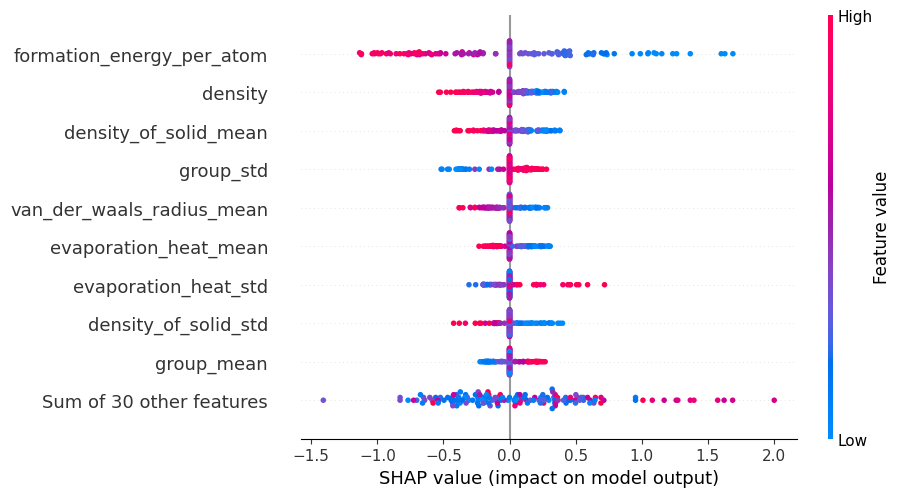

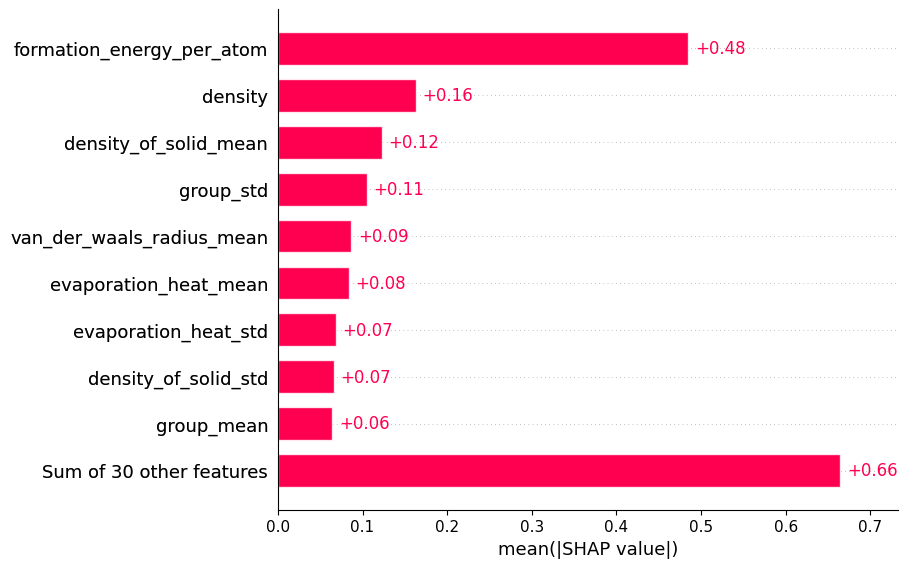

In [22]:
# Calculate SHAP Values for test set
explainer = shap.KernelExplainer(model.predict, shap.sample(X_train_scaled,100))
shap_values = explainer(X_test_scaled)
#SHAP values as both as beeswarm and bar plots

# Create an Explanation object with feature names
expl = shap.Explanation(values=shap_values,
                        base_values=explainer.expected_value,
                        data=X_test_scaled,
                        feature_names=X.columns)

# Plot SHAP values...
#... as beeswarm plot
shap.plots.beeswarm(expl)
#... as bar plot
shap.plots.bar(expl)

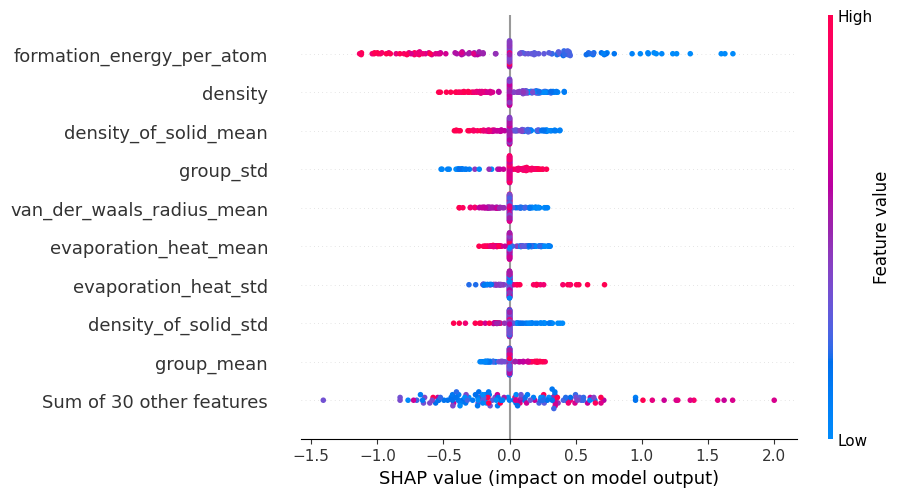

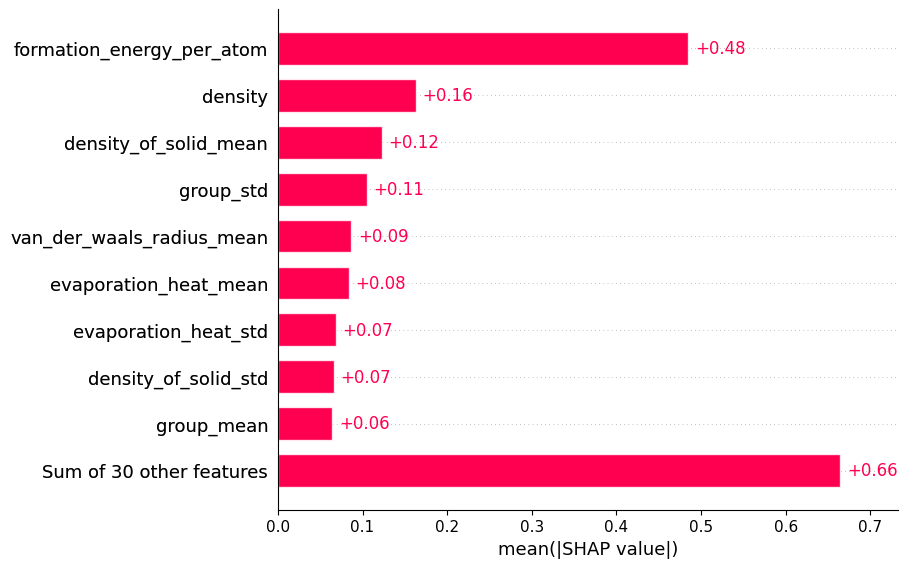

In [33]:
import matplotlib.pyplot as plt

# Plot SHAP values...
#... as beeswarm plot
shap.plots.beeswarm(expl)
#... as bar plot
shap.plots.bar(expl)
# Save as PDF
plt.savefig("shap_SVR.pdf", bbox_inches='tight', format='pdf')
plt.close()  # Close the plot to avoid display issues


In [36]:
X

,density,formation_energy_per_atom,energy_above_hull,atom_mass_mean,atom_mass_std,Z_mean,Z_std,group_mean,group_std,row_mean,row_std,mendeleev_no_mean,mendeleev_no_std,iupac_ordering_mean,iupac_ordering_std,average_ionic_radius_mean,average_ionic_radius_std,atomic_radius_mean,atomic_radius_std,atomic_radius_calculated_mean,atomic_radius_calculated_std,van_der_waals_radius_mean,van_der_waals_radius_std,X_mean,X_std,electron_affinity_mean,electron_affinity_std,ionization_energy_mean,ionization_energy_std,density_of_solid_mean,density_of_solid_std,molar_volume_mean,molar_volume_std,fusion_heat_mean,fusion_heat_std,evaporation_heat_mean,evaporation_heat_std,specific_heat_mean,specific_heat_std
0,5.967646,-0.305716,0.098312,73.279067,31.299080,32.666667,12.762793,14.666667,2.624669,4.000000,0.816497,87.666667,11.897712,89.333333,12.364825,0.949722,0.096840,1.250000,0.254951,1.156667,0.349698,1.920000,0.135892,2.490000,0.425284,2.248389,0.849311,9.916685,1.758155,5496.545332,3631.543621,15.193333,3.889733,7.916667,4.761634,98.053333,110.615679,0.472333,0.193105
1,6.576090,-0.260466,0.066818,88.945890,40.964795,38.666667,16.213849,14.666667,2.624669,4.333333,0.942809,87.333333,11.614168,89.000000,12.083046,1.080000,0.160647,1.333333,0.249444,1.226667,0.318991,1.963333,0.127105,2.390000,0.326905,2.146875,0.717999,9.462501,1.334313,5796.666667,3534.650698,17.173333,6.413581,9.566667,6.072409,102.183333,108.185892,0.385667,0.228085
2,6.373934,-0.210889,0.116396,88.945890,40.964795,38.666667,16.213849,14.666667,2.624669,4.333333,0.942809,87.333333,11.614168,89.000000,12.083046,1.080000,0.160647,1.333333,0.249444,1.226667,0.318991,1.963333,0.127105,2.390000,0.326905,2.146875,0.717999,9.462501,1.334313,5796.666667,3534.650698,17.173333,6.413581,9.566667,6.072409,102.183333,108.185892,0.385667,0.228085
3,5.320520,-1.243946,0.025765,66.263067,38.001726,29.333333,16.131405,14.000000,2.160247,3.666667,1.247219,87.000000,12.328828,86.000000,10.424331,1.002222,0.252122,1.116667,0.408928,1.090000,0.478957,1.826667,0.241431,2.516667,0.660824,1.190024,0.280016,10.327613,2.495842,5712.874808,3906.285741,13.526667,2.923062,12.276667,9.800681,97.773333,111.031840,0.494000,0.302259
4,4.138469,-0.407245,0.038285,53.106867,39.528162,24.000000,16.673332,14.666667,2.624669,3.333333,1.247219,90.333333,13.695092,90.000000,12.832251,1.042222,0.198463,1.066667,0.410961,0.973333,0.494930,1.793333,0.242808,2.843333,0.655862,2.126104,1.053143,11.387307,2.707886,4483.441609,4271.691505,15.006667,3.349352,6.266667,4.700031,93.776667,113.501396,0.544000,0.282596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1419,3.901772,-2.980085,0.000000,55.848993,35.079400,24.750000,14.872374,6.250000,6.533567,3.750000,1.299038,44.500000,38.147739,44.250000,38.680583,1.075000,0.379589,1.525000,0.673146,1.717500,0.809271,2.235000,0.552879,1.972500,1.272819,1.295568,1.219509,8.457864,5.281427,3619.071500,3855.162776,25.030000,18.588214,8.337500,11.379961,192.560000,231.924237,0.666500,0.388858
1420,4.194014,-2.638313,0.000000,57.590368,37.138772,25.500000,15.771810,7.000000,6.633250,3.750000,1.299038,46.750000,39.015221,46.500000,39.607449,1.067500,0.385689,1.500000,0.677311,1.675000,0.803010,2.217500,0.555760,2.002500,1.278287,1.394481,1.186626,8.549481,5.260082,4161.571500,4792.943375,24.755000,18.824348,6.787500,8.703865,168.560000,190.891937,0.664500,0.391004
1421,3.103076,-2.466064,0.000000,78.211195,57.360685,33.500000,22.643984,5.500000,6.689544,4.250000,1.299038,35.000000,37.229021,38.500000,37.619809,1.173750,0.315384,1.725000,0.480234,1.890000,0.688586,2.330000,0.456508,1.540000,0.948552,1.418947,1.283917,7.117037,3.451624,3464.925101,3402.152426,29.007500,15.621683,7.022500,5.899603,106.527500,77.746680,0.557500,0.403599
1422,3.583406,-3.568947,0.000000,54.090456,33.148734,24.000000,14.035669,5.500000,6.689544,3.750000,1.299038,36.750000,38.173125,42.000000,3